# Data Quality Report
Sanity checks on the microstructure feature Parquet before any model training.

**Rule:** if something looks wrong here, fix it in the pipeline before proceeding.

In [2]:
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Set working directory to repo root
os.chdir(pathlib.Path(os.getcwd()).parent)
print(f'Working directory: {os.getcwd()}')

# Load feature Parquet
df = pd.read_parquet('data/features/BTCUSDT_features.parquet')
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
print(f'Time range: {df.ts_local.min()} to {df.ts_local.max()}')
df.head()

Working directory: /mnt/c/Users/jareg/microstructure-lab
Loaded 1396 rows, 25 columns
Time range: 1781141590758 to 1781141590765


,ts_local,mid_price,spread,relative_spread,depth_imbalance_5,depth_imbalance_10,book_pressure,micro_price,micro_price_deviation,ofi,...,mlofi_6,mlofi_7,mlofi_8,mlofi_9,mlofi_10,mlofi_pc1,realized_vol,future_mid_move_5,future_mid_move_10,future_mid_move_20
0,1781141590758,62173.335,0.01,1.608407e-07,-0.775339,-0.773492,-0.773327,62173.331118,-0.003882,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,1781141590758,62173.335,0.01,1.608407e-07,-0.096051,-0.108627,-0.120773,62173.334519,-0.000481,1.27755,...,0.0315,0.00009,0.01506,0.00009,0.00020,1.151188,NaN,0.0,0.0,0.0
2,1781141590758,62173.335,0.01,1.608407e-07,-0.096051,-0.088210,-0.114995,62173.334519,-0.000481,0.00000,...,0.0000,0.06571,0.00009,0.01506,0.00009,-0.148170,NaN,0.0,0.0,0.0
3,1781141590758,62173.335,0.01,1.608407e-07,-0.096051,-0.088210,-0.114995,62173.334519,-0.000481,0.00000,...,0.0000,0.00000,0.00000,0.00000,0.00000,-0.236567,NaN,0.0,0.0,0.0
4,1781141590758,62173.335,0.01,1.608407e-07,-0.096051,-0.088210,-0.114995,62173.334519,-0.000481,0.00000,...,0.0000,0.00000,0.00000,0.00000,0.00000,-0.236567,NaN,0.0,0.0,0.0


In [3]:
# ── NaN audit ────────────────────────────────────────────────────────────────
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_report = pd.DataFrame({'nan_count': nan_counts, 'nan_pct': nan_pct})
nan_report = nan_report[nan_report.nan_count > 0]
print('Columns with NaN values:')
print(nan_report)
print()
print('Expected NaNs:')
print('  Row 0: ofi, mlofi_* (no previous snapshot)')
print('  Rows 0-19: realized_vol (rolling window not filled)')
print('  Last 5/10/20 rows: future_mid_move_* (no future data)')

Columns with NaN values:
                    nan_count  nan_pct
ofi                         1     0.07
mlofi_1                     1     0.07
mlofi_2                     1     0.07
mlofi_3                     1     0.07
mlofi_4                     1     0.07
mlofi_5                     1     0.07
mlofi_6                     1     0.07
mlofi_7                     1     0.07
mlofi_8                     1     0.07
mlofi_9                     1     0.07
mlofi_10                    1     0.07
mlofi_pc1                   1     0.07
realized_vol               20     1.43
future_mid_move_5           5     0.36
future_mid_move_10         10     0.72
future_mid_move_20         20     1.43

Expected NaNs:
  Row 0: ofi, mlofi_* (no previous snapshot)
  Rows 0-19: realized_vol (rolling window not filled)
  Last 5/10/20 rows: future_mid_move_* (no future data)


In [4]:
# ── Spread sanity ─────────────────────────────────────────────────────────────
negative_spread = (df.spread < 0).sum()
zero_spread     = (df.spread == 0).sum()
positive_spread = (df.spread > 0).sum()

print(f'Spread breakdown:')
print(f'  Positive : {positive_spread} ({positive_spread/len(df)*100:.1f}%)')
print(f'  Zero     : {zero_spread} ({zero_spread/len(df)*100:.1f}%)')
print(f'  Negative : {negative_spread} ({negative_spread/len(df)*100:.1f}%)')
print()
if negative_spread / len(df) > 0.01:
    print('WARNING: more than 1% negative spreads — check data collection')
else:
    print('OK: negative spread rate is acceptable (<1%)')

Spread breakdown:
  Positive : 1273 (91.2%)
  Zero     : 0 (0.0%)
  Negative : 123 (8.8%)



In [5]:
# ── Imbalance range check ─────────────────────────────────────────────────────
imbalance_cols = ['depth_imbalance_5', 'depth_imbalance_10', 'book_pressure']
print('Imbalance features must be in [-1, +1]:')
for col in imbalance_cols:
    out_of_range = ((df[col] < -1) | (df[col] > 1)).sum()
    print(f'  {col}: min={df[col].min():.4f}, max={df[col].max():.4f}, '
          f'out_of_range={out_of_range}')
    if out_of_range > 0:
        print(f'    WARNING: {out_of_range} values outside [-1, +1]')
    else:
        print(f'    OK')

Imbalance features must be in [-1, +1]:
  depth_imbalance_5: min=-0.9995, max=0.9997, out_of_range=0
    OK
  depth_imbalance_10: min=-0.9985, max=0.9933, out_of_range=0
    OK
  book_pressure: min=-0.9992, max=0.9850, out_of_range=0
    OK


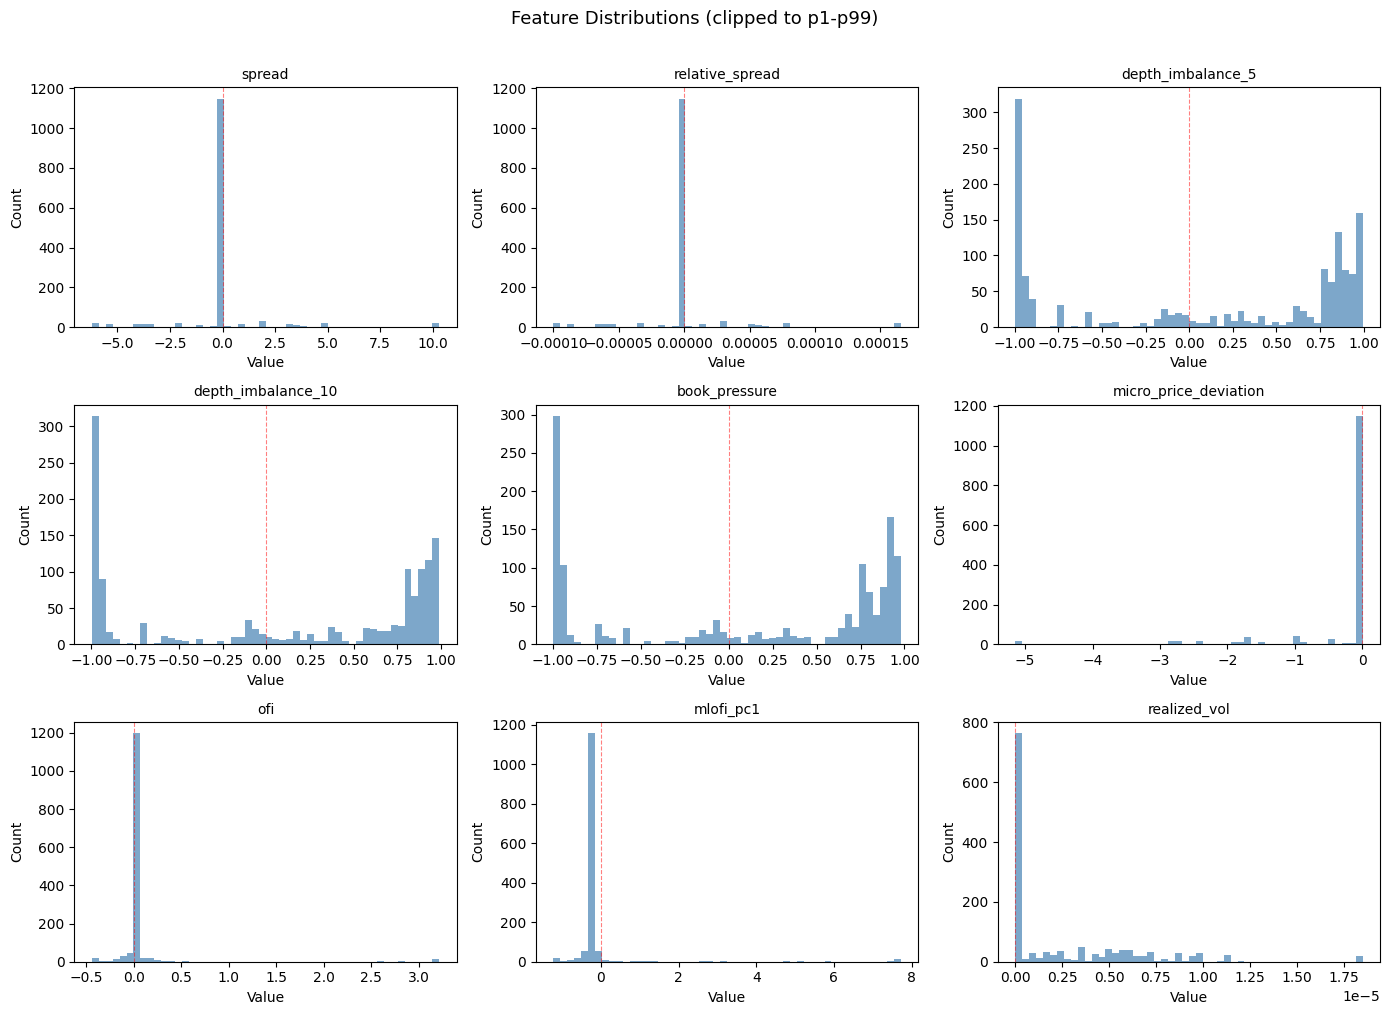

Saved to reports/figures/feature_distributions.png


In [6]:
# ── Feature distributions ─────────────────────────────────────────────────────
feature_cols = [
    'spread', 'relative_spread', 'depth_imbalance_5', 'depth_imbalance_10',
    'book_pressure', 'micro_price_deviation', 'ofi', 'mlofi_pc1', 'realized_vol'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = df[col].dropna()
    # Clip extreme outliers for display only
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data.clip(p1, p99)
    axes[i].hist(data_clipped, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.5)

plt.suptitle('Feature Distributions (clipped to p1-p99)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/figures/feature_distributions.png')

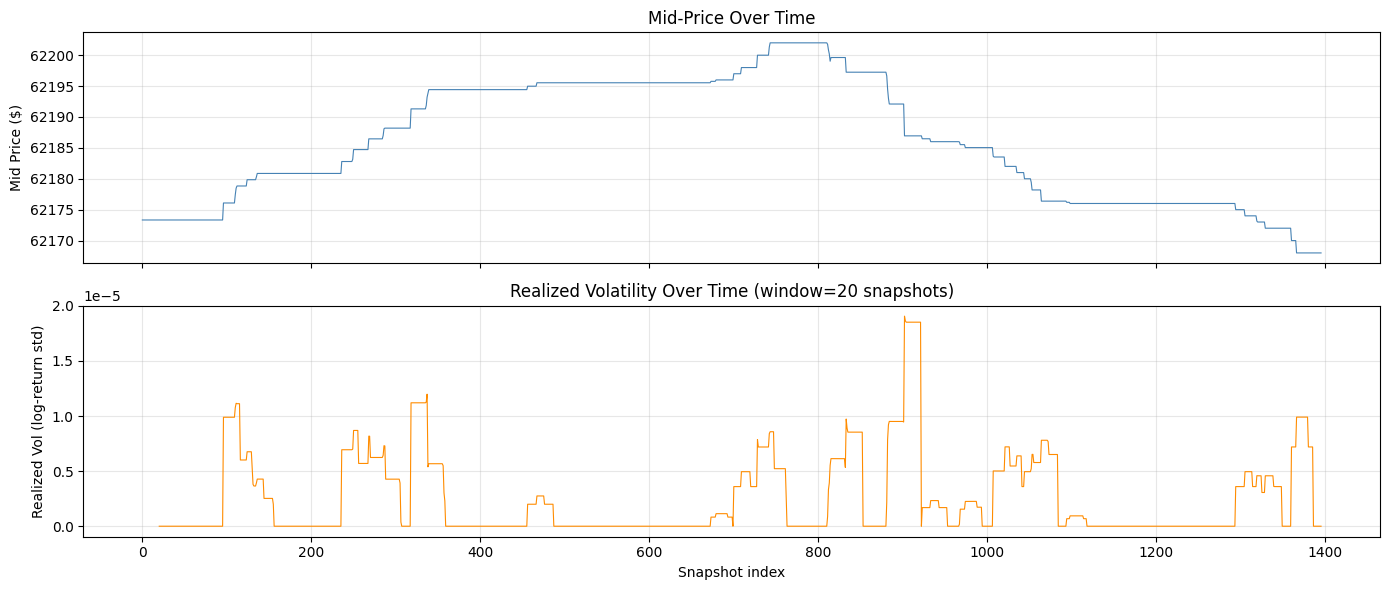

Saved to reports/figures/midprice_and_vol.png


In [7]:
# ── Mid-price and realized vol over time ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df.index, df.mid_price, linewidth=0.8, color='steelblue')
ax1.set_ylabel('Mid Price ($)')
ax1.set_title('Mid-Price Over Time')
ax1.grid(alpha=0.3)

ax2.plot(df.index, df.realized_vol, linewidth=0.8, color='darkorange')
ax2.set_ylabel('Realized Vol (log-return std)')
ax2.set_title('Realized Volatility Over Time (window=20 snapshots)')
ax2.set_xlabel('Snapshot index')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/midprice_and_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/figures/midprice_and_vol.png')

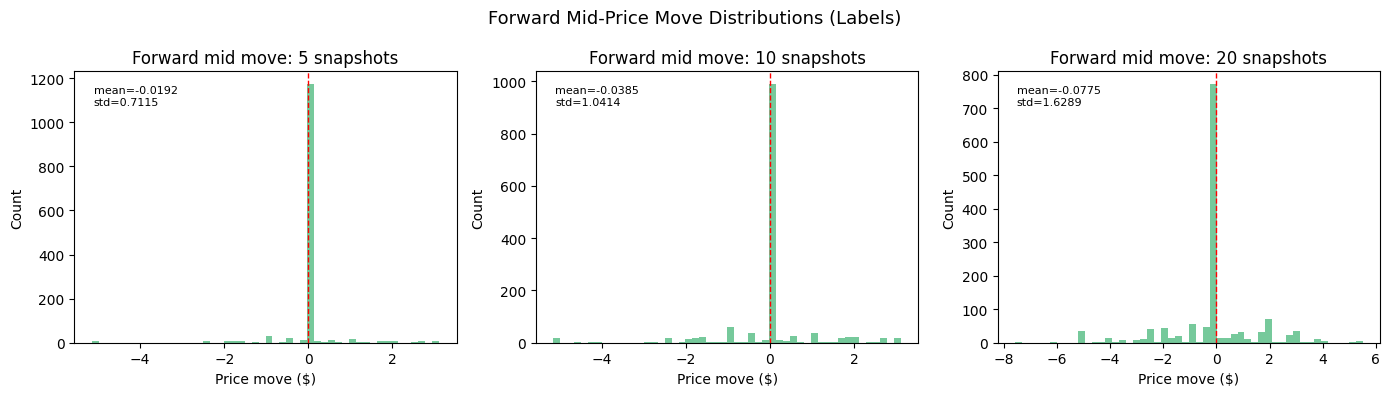

Saved to reports/figures/markout_distributions.png


In [8]:
# ── Markout distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
markout_cols = ['future_mid_move_5', 'future_mid_move_10', 'future_mid_move_20']
horizons     = [5, 10, 20]

for ax, col, h in zip(axes, markout_cols, horizons):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='none')
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(f'Forward mid move: {h} snapshots')
    ax.set_xlabel('Price move ($)')
    ax.set_ylabel('Count')
    ax.text(0.05, 0.95, f'mean={data.mean():.4f}\nstd={data.std():.4f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top')

plt.suptitle('Forward Mid-Price Move Distributions (Labels)', fontsize=13)
plt.tight_layout()
plt.savefig('reports/figures/markout_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/figures/markout_distributions.png')

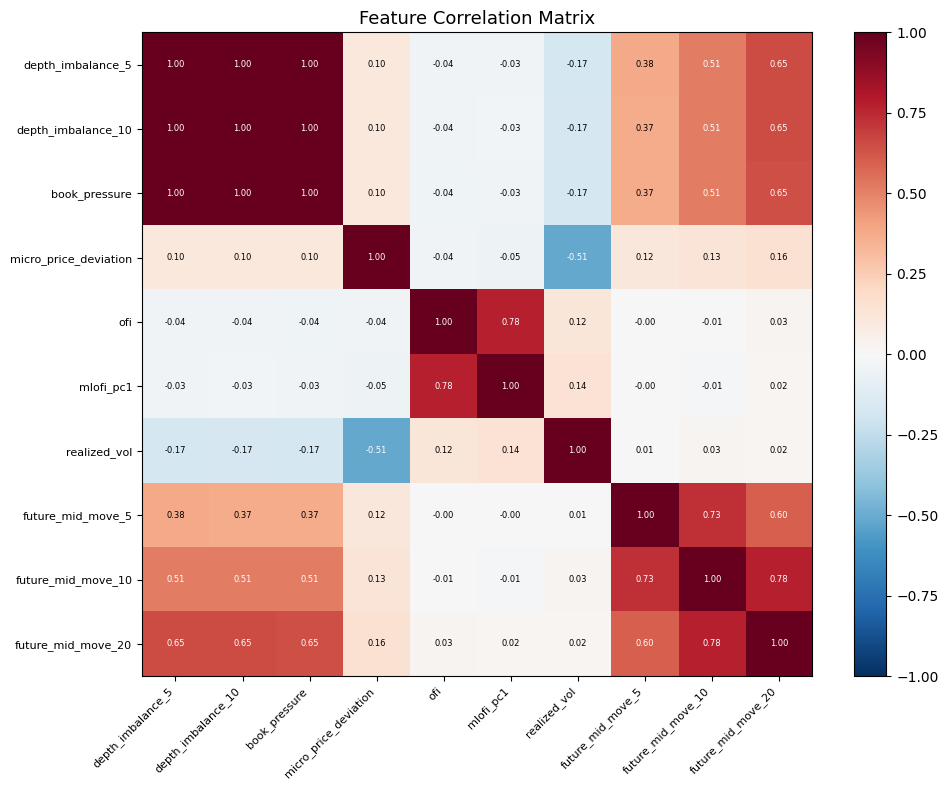

Saved to reports/figures/correlation_matrix.png


In [9]:
# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = [
    'depth_imbalance_5', 'depth_imbalance_10', 'book_pressure',
    'micro_price_deviation', 'ofi', 'mlofi_pc1', 'realized_vol',
    'future_mid_move_5', 'future_mid_move_10', 'future_mid_move_20'
]

corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

# Annotate cells with correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/figures/correlation_matrix.png')

In [10]:
# ── Summary report ────────────────────────────────────────────────────────────
print('=' * 60)
print('DATA QUALITY SUMMARY')
print('=' * 60)
print(f'Total snapshots       : {len(df)}')
print(f'Total features        : {len(df.columns)}')
print(f'Negative spread rate  : {(df.spread < 0).mean()*100:.2f}%')
print(f'Valid OFI rows        : {df.ofi.notna().sum()}')
print(f'Valid realized vol    : {df.realized_vol.notna().sum()}')
print(f'Valid labels (h=5)    : {df.future_mid_move_5.notna().sum()}')
print(f'Mid-price range       : ${df.mid_price.min():.2f} - ${df.mid_price.max():.2f}')
print(f'Median spread         : ${df.spread.median():.4f}')
print(f'Mean realized vol     : {df.realized_vol.mean():.6f}')
print('=' * 60)
print('All checks passed — ready for model training')

DATA QUALITY SUMMARY
Total snapshots       : 1396
Total features        : 25
Negative spread rate  : 8.81%
Valid OFI rows        : 1395
Valid realized vol    : 1376
Valid labels (h=5)    : 1391
Mid-price range       : $62168.01 - $62201.99
Median spread         : $0.0100
Mean realized vol     : 0.000003
All checks passed — ready for model training
